# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

# 4.3 Visualizing Text Data Lab

For this lab, I used the COVID-19 dataset `full_grouped.csv`. The dataset contains text-based fields such as Country/Region and WHO Region. I created three visualizations to examine patterns in those text fields.

Dataset Source

Dataset: COVID-19 Global Cases (`full_grouped.csv`)

This dataset contains worldwide COVID-19 case information organized by country/region and date. It includes text fields such as Country/Region and WHO Region, which are used in this lab to demonstrate text visualization techniques.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("full_grouped.csv")

df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


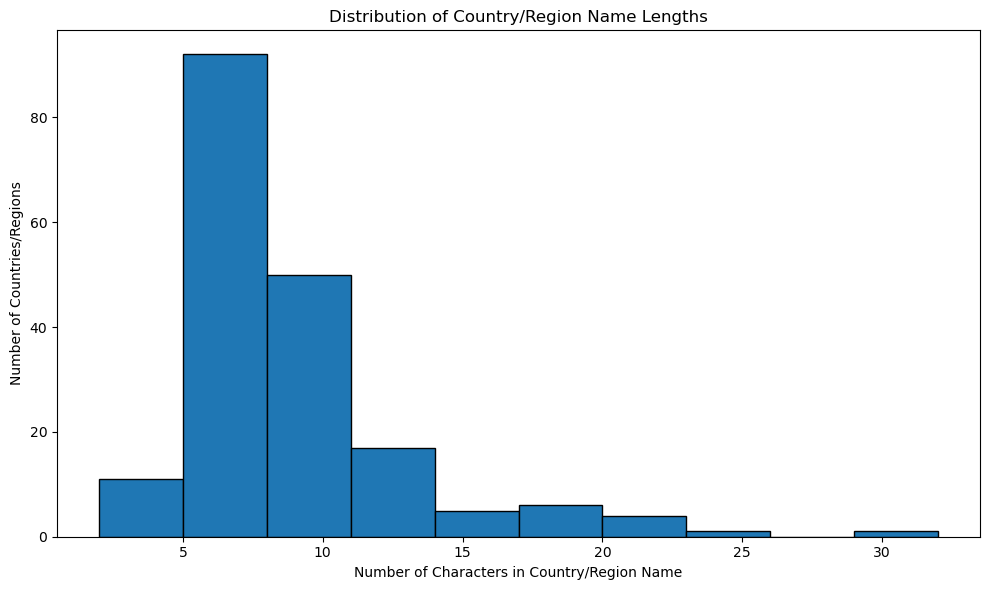

In [5]:
country_name_lengths = (
    df["Country/Region"]
    .dropna()
    .drop_duplicates()
    .str.len()
)

plt.figure(figsize=(10, 6))
plt.hist(country_name_lengths, bins=10, edgecolor="black")
plt.title("Distribution of Country/Region Name Lengths")
plt.xlabel("Number of Characters in Country/Region Name")
plt.ylabel("Number of Countries/Regions")
plt.tight_layout()
plt.show()

### Visualization 1 Interpretation

This histogram shows the distribution of character lengths for unique country and region names in the COVID-19 dataset. Most names are between about 5 and 10 characters long, while only a few names are much longer. This shows that text data can be analyzed by measuring patterns in the structure of the words and labels.


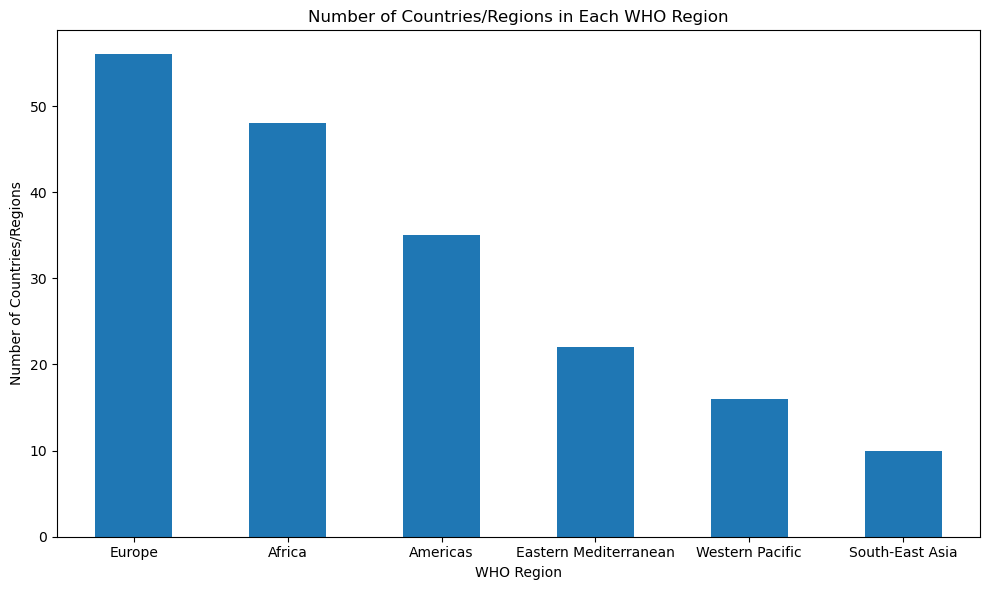

In [3]:
countries_by_region = (
    df[["Country/Region", "WHO Region"]]
    .drop_duplicates()
    .groupby("WHO Region")["Country/Region"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
countries_by_region.plot(kind="bar")
plt.title("Number of Countries/Regions in Each WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Number of Countries/Regions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visualization 2 Interpretation

This chart shows how many unique countries or regions are included in each WHO Region category. Europe has the largest number of countries represented, while some regions have fewer locations, showing that the dataset is not evenly distributed across WHO regions.

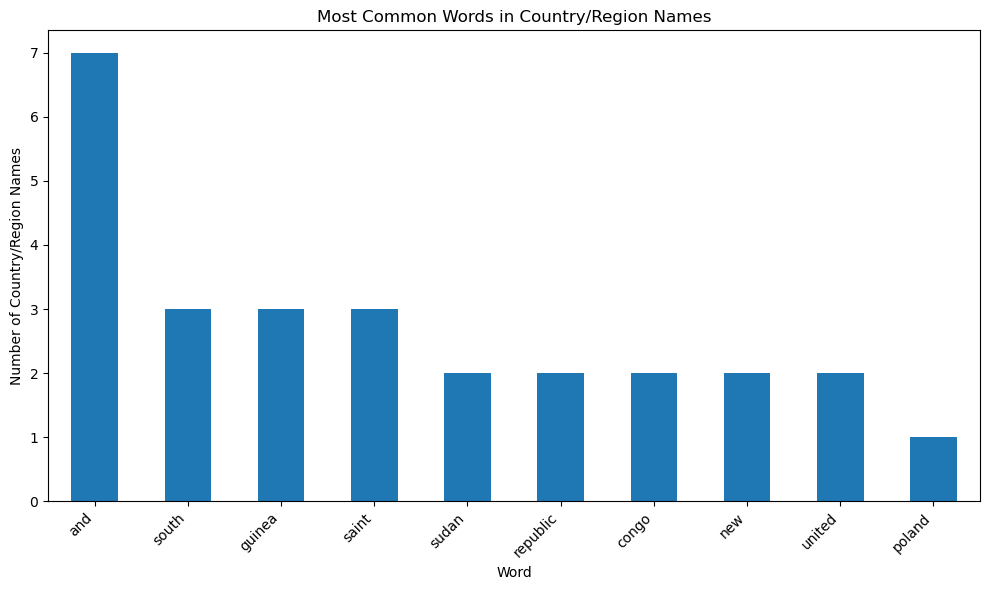

In [4]:
from collections import Counter
import re

country_words = (
    df["Country/Region"]
    .dropna()
    .drop_duplicates()
    .str.lower()
    .str.replace(r"[^a-z\s]", "", regex=True)
    .str.split()
)

all_words = [word for country in country_words for word in country]

common_words = (
    pd.Series(Counter(all_words))
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
common_words.plot(kind="bar")
plt.title("Most Common Words in Country/Region Names")
plt.xlabel("Word")
plt.ylabel("Number of Country/Region Names")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Visualization 3 Interpretation

This chart identifies the most common words appearing in the country and region names in the dataset. Words such as “islands,” “republic,” or “united” may appear frequently because several locations share those naming patterns, showing how text analysis can uncover common language within categorical labels.

Conclusion

These visualizations used the text fields Country/Region and WHO Region to identify patterns in how COVID-19 reporting locations are labeled and grouped. The results show that text data can be counted, categorized, and broken into individual words to reveal meaningful geographic and naming patterns.